In [4]:
# we will predict who is gonna survive in titanic

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("titanic_train.csv")

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Gender       891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [7]:
df = df.drop('Name', axis=1)
df = df.drop('PassengerId', axis=1)
df = df.drop('Ticket', axis=1)
df = df.drop('Cabin', axis=1)

In [8]:
print(df.duplicated().sum())

111


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Gender    891 non-null    str    
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(2)
memory usage: 55.8 KB


In [10]:
df['Age'] = df['Age'].fillna(df["Age"].median())

In [11]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [12]:
print(df.isnull().sum())

Survived    0
Pclass      0
Gender      0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [13]:
print(df.duplicated().sum())

116


In [14]:
df = df.drop_duplicates()

In [15]:
print(df.duplicated().sum())

0


In [16]:
df.info()

<class 'pandas.DataFrame'>
Index: 775 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  775 non-null    int64  
 1   Pclass    775 non-null    int64  
 2   Gender    775 non-null    str    
 3   Age       775 non-null    float64
 4   SibSp     775 non-null    int64  
 5   Parch     775 non-null    int64  
 6   Fare      775 non-null    float64
 7   Embarked  775 non-null    str    
dtypes: float64(2), int64(4), str(2)
memory usage: 54.5 KB


In [17]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,775.000000,775.000000,775.000000,775.000000,775.000000,775.000000
mean,0.412903,2.246452,29.581187,0.529032,0.420645,34.878403
std,0.492674,0.853574,13.766359,0.990326,0.840565,52.408474
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,21.000000,0.000000,0.000000,8.050000
50%,0.000000,3.000000,28.000000,0.000000,0.000000,15.900000
75%,1.000000,3.000000,36.000000,1.000000,1.000000,34.197900
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [18]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,775.000000,775.000000,775.000000,775.000000,775.000000,775.000000
mean,0.412903,2.246452,29.581187,0.529032,0.420645,34.878403
std,0.492674,0.853574,13.766359,0.990326,0.840565,52.408474
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,21.000000,0.000000,0.000000,8.050000
50%,0.000000,3.000000,28.000000,0.000000,0.000000,15.900000
75%,1.000000,3.000000,36.000000,1.000000,1.000000,34.197900
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [19]:
df.nunique()

Survived      2
Pclass        3
Gender        2
Age          88
SibSp         7
Parch         7
Fare        248
Embarked      3
dtype: int64

In [20]:
def classify_features(df, low_cardinality_threshold=15):
    categorical_features     = []   # low-cardinality non-numeric
    high_cardinality_features = []  # high-cardinality non-numeric (needs encoding strategy)
    discrete_features        = []   # integer-valued / countable
    continuous_features      = []   # real-valued / measurable
    unhandled                = []   # datetime, complex, etc.

    for column in df.columns:
        s = df[column]
        n_unique = s.nunique(dropna=True)

        if n_unique == 0:
            continue                          # all-NaN column

        # Non-numeric (includes bool, category, string, object)
        if not pd.api.types.is_numeric_dtype(s) or pd.api.types.is_bool_dtype(s):
            if n_unique <= low_cardinality_threshold:
                categorical_features.append(column)
            else:
                high_cardinality_features.append(column)

        # Numeric (excluding bool which was caught above)
        elif pd.api.types.is_integer_dtype(s):
            discrete_features.append(column)

        elif pd.api.types.is_float_dtype(s):
            continuous_features.append(column)

        else:
            unhandled.append(column)

    return (categorical_features, high_cardinality_features,
            discrete_features, continuous_features, unhandled)

In [21]:
categorical_features, non_categorical_features, discrete_features, continuous_features, unhandled = classify_features(df)
print(categorical_features, non_categorical_features, discrete_features, continuous_features)

['Gender', 'Embarked'] [] ['Survived', 'Pclass', 'SibSp', 'Parch'] ['Age', 'Fare']


C:\Users\nihar\AppData\Local\Temp\ipykernel_21412\3599633629.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gender', data=df, palette='hls')
C:\Users\nihar\AppData\Local\Temp\ipykernel_21412\3599633629.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Embarked', data=df, palette='viridis')


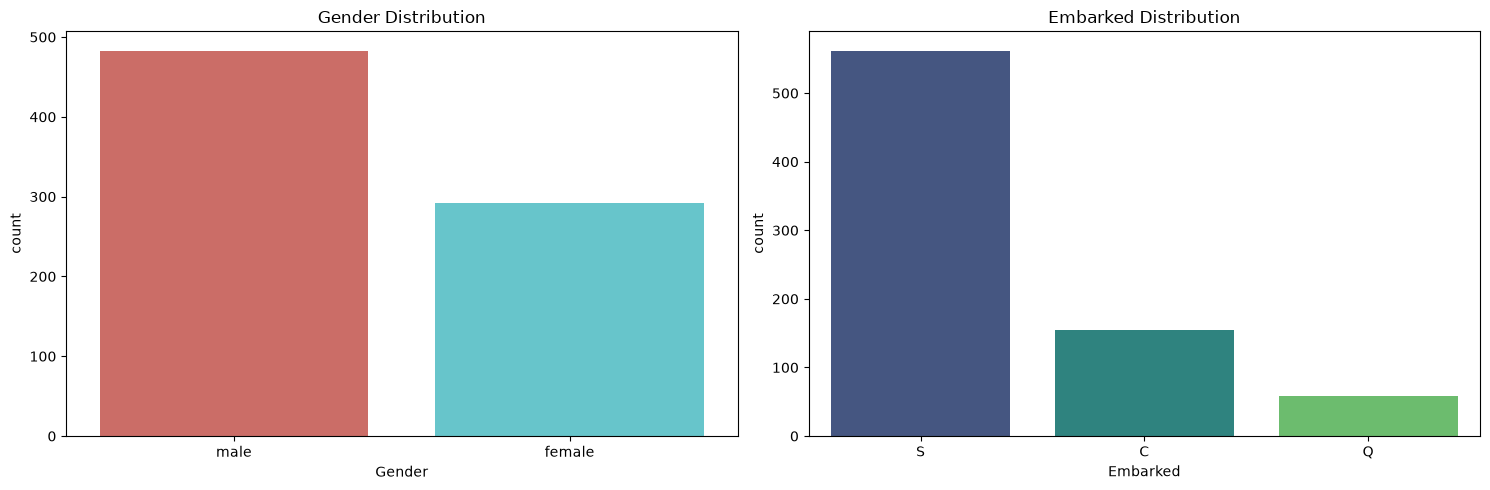

In [22]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.countplot(x='Gender', data=df, palette='hls')
plt.title('Gender Distribution')

plt.subplot(1, 2, 2)
sns.countplot(x='Embarked', data=df, palette='viridis')
plt.title('Embarked Distribution')

plt.tight_layout()
plt.show()



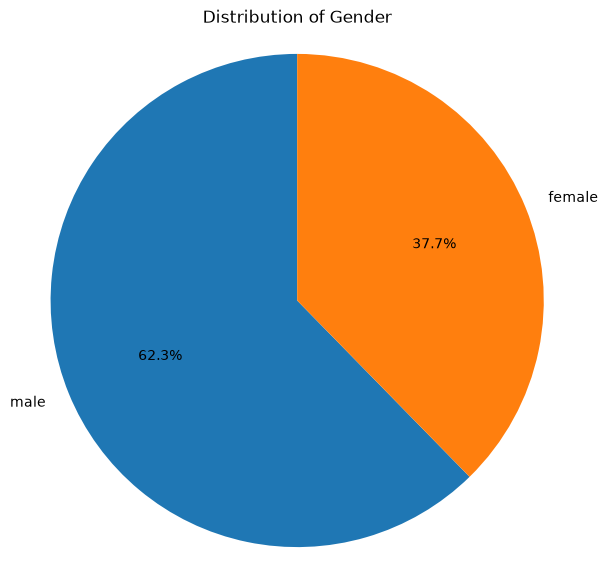

In [23]:
counts = df['Gender'].value_counts()
    
plt.figure(figsize=(7, 7))
plt.pie(
        counts.values,
        labels=counts.index,
        autopct='%1.1f%%',
        startangle=90
)
plt.title(f'Distribution of Gender')
plt.axis('equal')
plt.show()

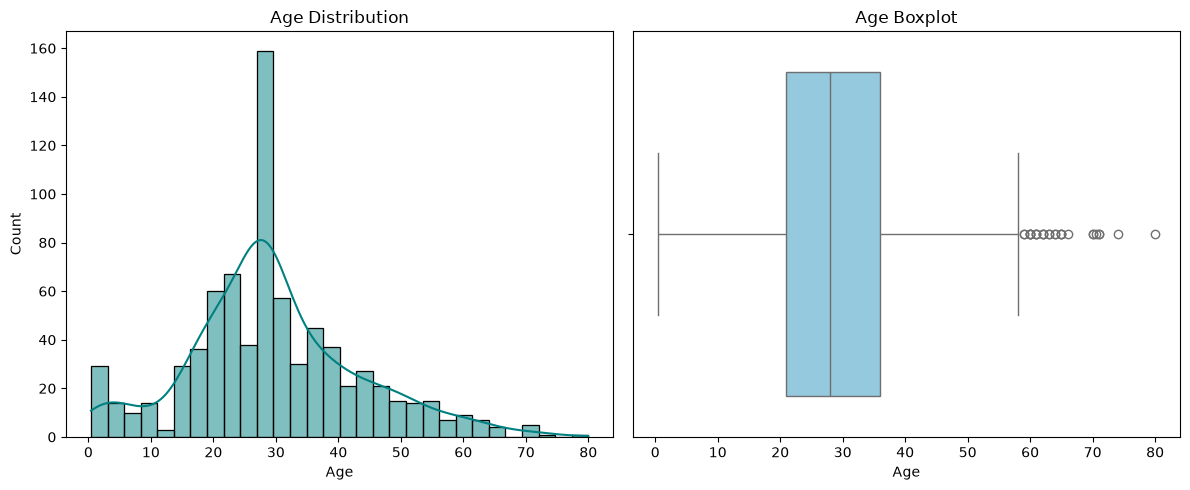

Age skewness: 0.442


In [24]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df['Age'], kde=True, color='teal', bins=30)
plt.title('Age Distribution')

plt.subplot(1,2,2)
sns.boxplot(x=df['Age'], color='skyblue')
plt.title('Age Boxplot')

plt.tight_layout()
plt.show()

print('Age skewness:', round(df['Age'].skew(), 3))

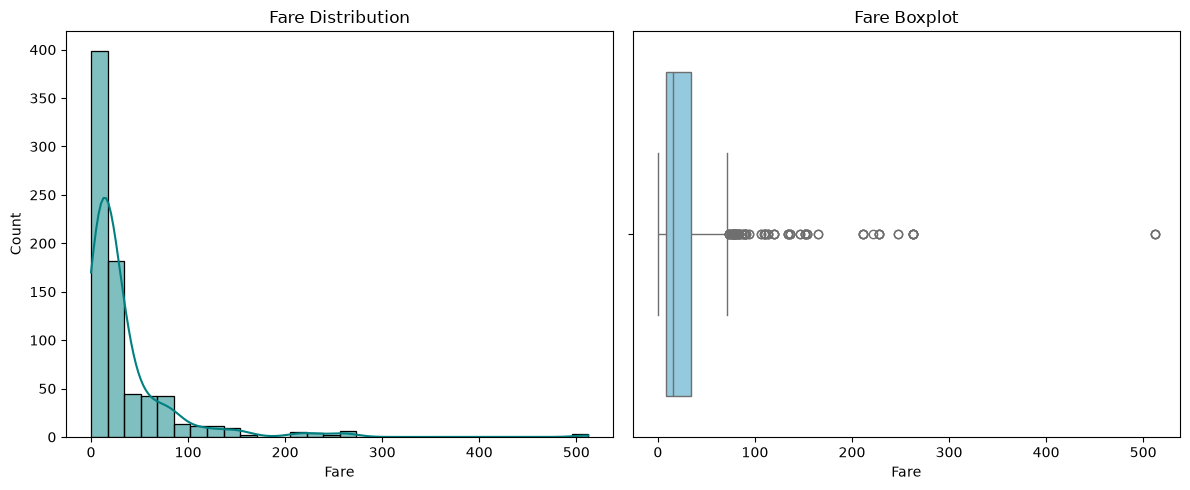

Fare Skewness: 4.55


In [25]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['Fare'], kde=True, color='teal', bins=30)
plt.title('Fare Distribution')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['Fare'], color='skyblue')
plt.title('Fare Boxplot')

plt.tight_layout()
plt.show()

print("Fare Skewness:", round(df['Fare'].skew(), 3))

C:\Users\nihar\AppData\Local\Temp\ipykernel_21412\3708768369.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Survived', y='Age', data=df, palette='hls')
C:\Users\nihar\AppData\Local\Temp\ipykernel_21412\3708768369.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Survived', y='Fare', data=df, palette='viridis')


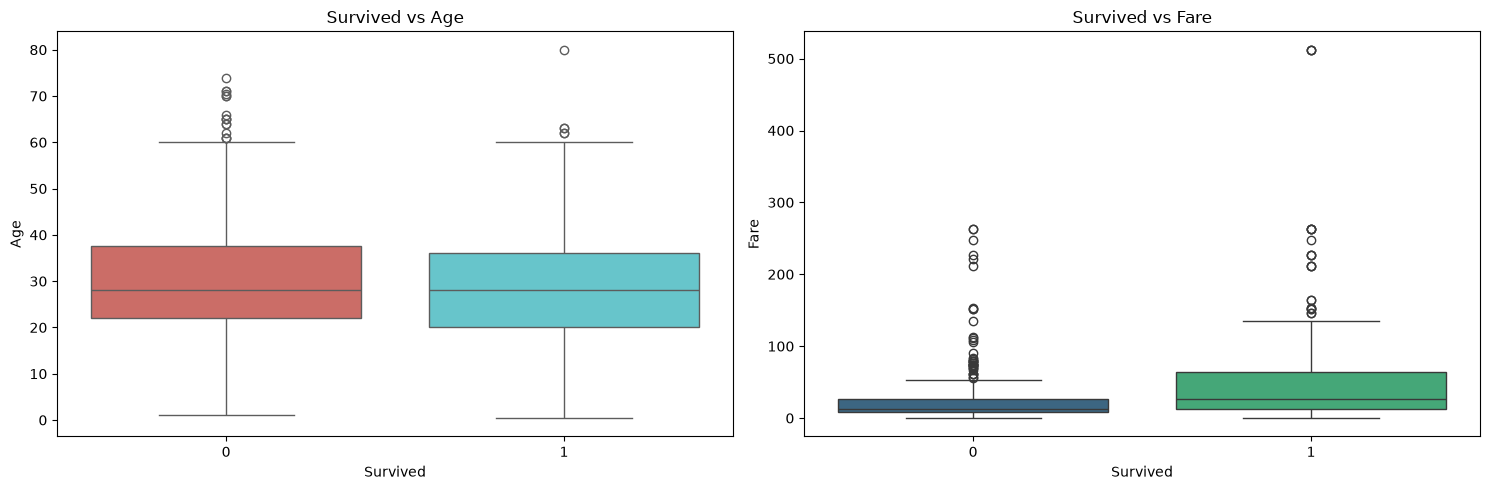

In [26]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x='Survived', y='Age', data=df, palette='hls')
plt.title('Survived vs Age')

plt.subplot(1, 2, 2)
sns.boxplot(x='Survived', y='Fare', data=df, palette='viridis')
plt.title('Survived vs Fare')

plt.tight_layout()
plt.show()

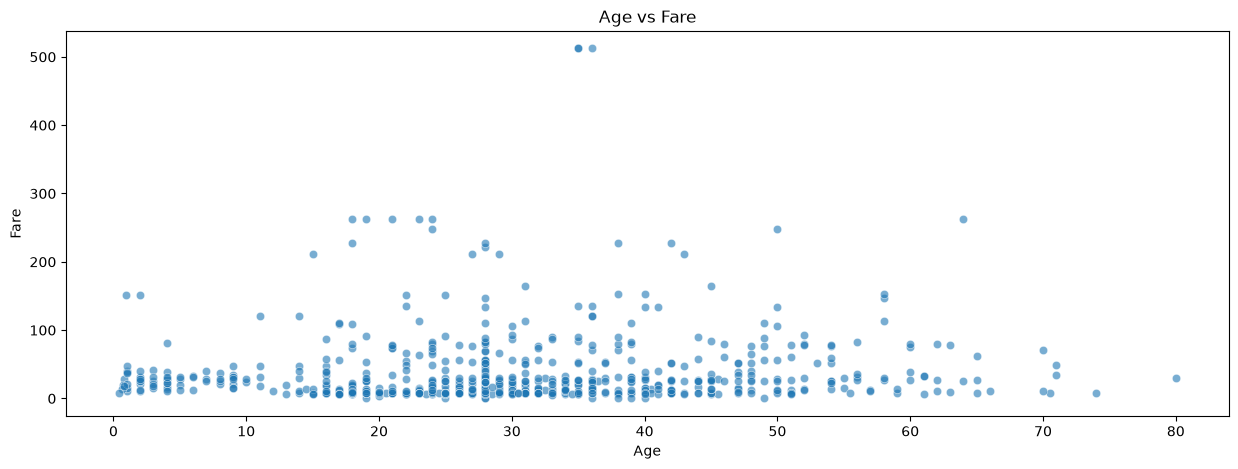

In [27]:
plt.figure(figsize=(15, 5))
sns.scatterplot(x='Age', y="Fare", data=df, alpha=0.6)
plt.title('Age vs Fare')
plt.show()

In [28]:
cat_cols = ['Gender', 'Embarked']

for col in cat_cols:
    dummies = pd.get_dummies(df[col], prefix=col, drop_first=False)
    df = pd.concat([df, dummies], axis=1)
    df = df.drop(col, axis=1)

In [29]:
from sklearn.preprocessing import StandardScaler

scale_cols = [
   'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'
]

scaler = StandardScaler()

df[scale_cols] = scaler.fit_transform(df[scale_cols])

df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Gender_female,Gender_male,Embarked_C,Embarked_Q,Embarked_S
0,0,0.883385,-0.551060,0.475876,-0.500754,-0.527515,False,True,False,False,True
1,1,-1.461216,0.611945,0.475876,-0.500754,0.695086,True,False,True,False,False
2,1,0.883385,-0.260308,-0.534545,-0.500754,-0.514627,True,False,False,False,True
3,1,-1.461216,0.393881,0.475876,-0.500754,0.347909,True,False,False,False,True
4,0,0.883385,0.393881,-0.534545,-0.500754,-0.512240,False,True,False,False,True


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [ ]:
X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (620, 10)
X_test : (155, 10)
y_train: (620,)
y_test : (155,)


In [32]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

In [36]:
y_pred = LogisticRegression(X_train)
print("LR Model Performance:")
print("  Accuracy  :", round(accuracy_score(y_test, y_pred), 4))
print("  Precision :", round(precision_score(y_test, y_pred), 4))
print("  Recall    :", round(recall_score(y_test, y_pred), 4))
print("  F1 Score  :", round(f1_score(y_test, y_pred), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Died', 'Survived']))

LR Model Performance:


InvalidParameterError: The 'y_pred' parameter of accuracy_score must be an array-like or a sparse array or matrix. Got LogisticRegression(penalty=       Pclass       Age     SibSp     Parch      Fare  Gender_female  \
429  0.883385  0.175818 -0.534545 -0.500754 -0.512240          False   
179  0.883385  0.466569 -0.534545 -0.500754 -0.665941          False   
672 -0.288915  2.937953 -0.534545 -0.500754 -0.465462          False   
227  0.883385 -0.660091 -0.534545 -0.500754 -0.527515          False   
383 -1.461216  0.393881  0.475876 -0.500754  0.326906           True   
..        ...       ...       ...       ...       ...            ...   
835 -1.46121...
771  0.883385  1.338822 -0.534545 -0.500754 -0.515979          False   
770  0.883385 -0.405684 -0.534545 -0.500754 -0.484555          False   

     Gender_male  Embarked_C  Embarked_Q  Embarked_S  
429         True       False       False        True  
179         True       False       False        True  
672         True       F